# 巡回セールスマン問題

## ライブラリのインポート

In [1]:
import numpy as np
import copy
import math
import random

## 各都市間の距離

In [2]:
def Check(route):
    d = 0
    if route.count(-1)==0:
        for k in range(len(route)):
            i = route[k-1]
            j = route[k]
#            print(i,j,dist[i][j])
            d += dist[i][j]
        return d
    return -route.count(-1)

## 縮退用

In [3]:
def Reduce(dist, v):
    dist_r = copy.deepcopy(dist)
    dist_c = copy.deepcopy(dist)
    rr = []
    for i in range(len(dist)):
        a = min(dist[i])
        if a==math.inf:
            a = 0
        rr.append(a)
        for j in range(len(dist[i])):
            dist_r[j][i] = dist[i][j] - a
    rc = []
    for i in range(len(dist)):
        a = min(dist_r[i])
        if a==math.inf:
            a = 0
        rc.append(a)
        for j in range(len(dist[i])):
            dist_c[j][i] = dist_r[i][j] - a
    return sum(rr)+sum(rc), dist_c, v
    

## 推定値用

In [4]:
def Estimation(node, v):
    cost = node[0]
    dist = node[1]
    va = [v[i] for i in range(len(v)-v.count(-1))]
    v0 = va[-2]
    v1 = va[-1]
    v2 = va[0]
    dist_c = copy.deepcopy(dist)
    rr = []
    for j in range(len(dist)):
        dist_c[v0][j] = math.inf
    for i in range(len(dist)):
        dist_c[i][v1] = math.inf
    dist_c[v1][v2] = math.inf

    rrc,dist_c,_ = Reduce(dist_c,v)
    return dist[v0][v1]+rrc+cost, dist_c, v    

## 各都市の位置の設定(以下のいづれかを実行)

図？の場合

In [5]:
MAX_CITY = 10
cities = [(math.cos(math.pi*2*i/MAX_CITY),math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]

図？の場合

In [6]:
MAX_CITY = 10
cities = [(math.cos(math.pi*2*i/MAX_CITY),math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]
#外側を小さい円で囲む
cities = cities+[(1.2*math.cos(math.pi*2*i/MAX_CITY),1.2*math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]
#外側を大きい円で囲む
#cities = cities+[(2*math.cos(math.pi*2*i/MAX_CITY),2*math.sin(math.pi*2*i/MAX_CITY)) for i in range(MAX_CITY)]
MAX_CITY = 20

図？の場合

In [17]:
MAX_CITY = 20
random.seed(2)
cities = [(random.uniform(-1,1),random.uniform(-1,1)) for i in range(MAX_CITY)]

## 各都市間の距離への変換

In [7]:
dist = np.zeros([MAX_CITY,MAX_CITY])

for i in range(MAX_CITY):
    dist[i][i] = math.inf
    for j  in range(i+1,MAX_CITY):
        dist[i][j] = np.sqrt((cities[i][0]-cities[j][0])**2+(cities[i][1]-cities[j][1])**2)
        dist[j][i] = dist[i][j]

## 0→1→2→3→4と巡回したときの距離

In [8]:
Check([0,2,1,4,3])

5.647706459584526

## 探索

最後の行に最適な選択結果が表示される

In [9]:
num_city = len(dist)
init_route = [-1]*num_city
init_route[0] = 0
min_dist = math.inf

init_node = Reduce(dist, init_route)

min_route = init_node
open_list = [init_node]
closed_list = []

while open_list:
    node = open_list.pop(0)#幅優先
#    route = open_list.pop(-1)#深さ優先
    route = node[2]
    closed_list.append(node)
    n = num_city - route.count(-1)
    print(n,node[0:2],route,Check(route))
    
    if n<num_city:
        rt = list(range(num_city))
        for i in range(num_city-route.count(-1)):
            rt.remove(route[i])
        node_tmp = []
        node_min_cost=math.inf
        for i in rt:
            new_route = copy.copy(route)
            new_route[n] = i
            a = Estimation(node[0:2],new_route)
            if node_min_cost>a[0]:
                node_min_cost=a[0]
                b = a
            print(a[0],a[2])
        open_list.append(b)

print('探索数')
print(len(closed_list))
print('答え')
min_node = closed_list[-1]
min_dist = min_node[0]
min_route = min_node[2]
print('最短距離')
print(min_dist)
print('ルート')
print(min_route)


1 (3.999999999999998, array([[       inf, 0.41803399, 0.9755705 , 1.41803399, 1.70211303,
        1.8       , 1.70211303, 1.41803399, 0.9755705 , 0.41803399,
        0.        , 0.50594562, 1.10321112, 1.58371544, 1.89323692,
        2.        , 1.89323692, 1.58371544, 1.10321112, 0.50594562],
       [0.41803399,        inf, 0.41803399, 0.9755705 , 1.41803399,
        1.70211303, 1.8       , 1.70211303, 1.41803399, 0.9755705 ,
        0.50594562, 0.        , 0.50594562, 1.10321112, 1.58371544,
        1.89323692, 2.        , 1.89323692, 1.58371544, 1.10321112],
       [0.9755705 , 0.41803399,        inf, 0.41803399, 0.9755705 ,
        1.41803399, 1.70211303, 1.8       , 1.70211303, 1.41803399,
        1.10321112, 0.50594562, 0.        , 0.50594562, 1.10321112,
        1.58371544, 1.89323692, 2.        , 1.89323692, 1.58371544],
       [1.41803399, 0.9755705 , 0.41803399,        inf, 0.41803399,
        0.9755705 , 1.41803399, 1.70211303, 1.8       , 1.70211303,
        1.58371544, 1.1

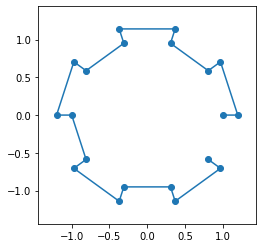

In [10]:
import matplotlib.pyplot as plt
 
# 乱数を生成
x,y = [],[]
for i in min_route:
    x.append(cities[i][0])
    y.append(cities[i][1])
c = np.array(cities)
max_range = max(max(c[:,0]),-min(c[:,0]),max(c[:,1]),-min(c[:,1]))
max_range *= 1.2


g = plt.subplot()
g.set_xlim([-max_range,max_range])
g.set_ylim([-max_range,max_range])
# 散布図を描画
g.plot(x, y,marker='o')
g.set_aspect('equal')